In [1]:
# ── Cell 1: Environment Setup ────────────────────────────────
import os
os.environ["HADOOP_HOME"]     = r"C:\hadoop"
os.environ["hadoop.home.dir"] = r"C:\hadoop"
os.environ["PATH"]            = r"C:\hadoop\bin;" + os.environ.get("PATH", "")
assert os.path.exists(r"C:\hadoop\bin\winutils.exe"), "winutils.exe missing!"
print("✓ HADOOP_HOME set")

✓ HADOOP_HOME set


In [2]:
# ── Cell 2: Imports ──────────────────────────────────────────
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, StringType
from pyspark.ml.clustering import KMeansModel, BisectingKMeansModel
from pyspark.ml.clustering import DistributedLDAModel, LocalLDAModel
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.linalg import VectorUDT
from pyspark.ml.functions import array_to_vector

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              davies_bouldin_score, calinski_harabasz_score)
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
import time, json, pickle, warnings
warnings.filterwarnings("ignore")

In [3]:
# ── Cell 3: SparkSession ─────────────────────────────────────
spark = SparkSession.builder \
    .appName("BagOfWords_Evaluation") \
    .master("local[1]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.adaptive.enabled", "false") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.python.worker.reuse", "false") \
    .config("spark.hadoop.hadoop.home.dir", r"C:\hadoop") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print(f"Spark UI: {spark.sparkContext.uiWebUrl}")

PAR_DIR = "./data/parquet"
os.makedirs("./outputs", exist_ok=True)


Spark UI: http://DESKTOP-6826D4K:4045


In [4]:
# ── Cell 4: Loader (same pattern as NB3) ─────────────────────
def load_spark_features(path, vector_cols):
    sdf = spark.read.parquet(path)
    for col_name in vector_cols:
        sdf = sdf.withColumn(col_name, array_to_vector(F.col(col_name)))
    return sdf

In [5]:
# ── Cell 5: Load Data ─────────────────────────────────────────
print("Loading data …")
FEAT_VCOLS  = ["tfidf_normalized", "pca_50_features"]
TFIDF_VCOLS = ["tf_features", "tfidf_features", "tfidf_normalized"]

train_sdf = load_spark_features(os.path.join(PAR_DIR, "train_features.parquet"), FEAT_VCOLS)
val_sdf   = load_spark_features(os.path.join(PAR_DIR, "val_features.parquet"),   FEAT_VCOLS)
test_sdf  = load_spark_features(os.path.join(PAR_DIR, "test_features.parquet"),  FEAT_VCOLS)
tfidf_sdf = load_spark_features(os.path.join(PAR_DIR, "tfidf_full.parquet"),     TFIDF_VCOLS)
train_sdf.cache(); val_sdf.cache(); test_sdf.cache(); tfidf_sdf.cache()
print(f"  Train={train_sdf.count():,}  Val={val_sdf.count():,}  Test={test_sdf.count():,}")

vocab_schema = StructType([
    StructField("wordID", IntegerType(), False),
    StructField("word",   StringType(),  False),
])
kos_vocab_sdf = spark.read.schema(vocab_schema).parquet(
    os.path.join(PAR_DIR, "kos_vocab.parquet"))
vocab_list = [r["word"] for r in kos_vocab_sdf.orderBy("wordID").collect()]

with open("./models/tfidf_pipeline_data.pkl", "rb") as f:
    pipeline_data = pickle.load(f)
cv_vocabulary = pipeline_data["cv_vocabulary"]
print(f"  CV vocab: {len(cv_vocabulary):,} | KOS vocab: {len(vocab_list):,}")

# Load cluster labels saved by NB3
labels_pd = pd.read_csv("./outputs/test_cluster_labels.csv")
print(f"  Cluster labels loaded: {len(labels_pd):,} test docs")
print(labels_pd.head())

Loading data …
  Train=2,453  Val=487  Test=490
  CV vocab: 6,898 | KOS vocab: 6,906
  Cluster labels loaded: 490 test docs
   docID  km_cluster  bkm_cluster  gmm_cluster  skm_cluster
0      7           9            7            3            3
1      9           9            7            4            0
2     24           3            0            8            4
3     36           0            7            9            0
4     47           7            6            8            0


In [6]:
# ── Cell 6: Load Models ───────────────────────────────────────
print("\nLoading Spark models …")
km_model  = KMeansModel.load("./models/kmeans_best")
bkm_model = BisectingKMeansModel.load("./models/bisecting_kmeans_best")
try:
    lda_model = DistributedLDAModel.load("./models/lda_best")
    print("  LDA: DistributedLDAModel")
except Exception:
    lda_model = LocalLDAModel.load("./models/lda_best")
    print("  LDA: LocalLDAModel")
with open("./models/gmm_final.pkl", "rb") as f:
    gmm_model = pickle.load(f)
with open("./outputs/training_results.json") as f:
    training_results = json.load(f)
print("  All models loaded ✓")


Loading Spark models …
  LDA: LocalLDAModel
  All models loaded ✓


In [8]:
# ── Cell 7: Collect numpy arrays ──────────────────────────────
print("\nCollecting numpy arrays …")
def sdf_to_numpy(sdf, feat_col="pca_50_features"):
    pdf = sdf.select("docID", feat_col).toPandas()
    X   = np.vstack(pdf[feat_col].apply(lambda v: v.toArray()).values)
    return pdf["docID"].values, X

test_ids, X_test = sdf_to_numpy(test_sdf)
X_test_norm = normalize(X_test)
# Align cluster labels to test_ids ordering
test_df_merged = pd.DataFrame({"docID": test_ids}).merge(labels_pd, on="docID")
km_labels  = test_df_merged["km_cluster"].values
bkm_labels = test_df_merged["bkm_cluster"].values
gmm_labels = test_df_merged["gmm_cluster"].values
print(f"  Aligned {len(km_labels):,} test docs to cluster labels")


  Aligned 490 test docs to cluster labels


In [9]:
# ── Cell 8: Spark Silhouette on test set (re-predict) ─────────
# predictionCol="cluster" must match what models were trained with
evaluator = ClusteringEvaluator(
    featuresCol="pca_50_features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)
km_test_preds  = km_model.transform(test_sdf)
bkm_test_preds = bkm_model.transform(test_sdf)
km_sil_spark   = evaluator.evaluate(km_test_preds)
bkm_sil_spark  = evaluator.evaluate(bkm_test_preds)
print(f"\n  KMeans Silhouette (Spark):  {km_sil_spark:.4f}")
print(f"  BKMeans Silhouette (Spark): {bkm_sil_spark:.4f}")


  KMeans Silhouette (Spark):  0.1132
  BKMeans Silhouette (Spark): 0.0742


In [10]:
# ── Cell 9: sklearn metrics ───────────────────────────────────
print("\nComputing sklearn metrics …")
n_sil = min(500, len(X_test_norm))
idx   = np.random.RandomState(42).choice(len(X_test_norm), n_sil, replace=False)

def safe_metric(fn, X, labels, name):
    try:
        v = fn(X, labels)
        print(f"  {name}: {v:.4f}")
        return round(float(v), 4)
    except Exception as e:
        print(f"  {name}: ERROR ({e})")
        return None

metrics = {}
for model_name, labels in [("KMeans", km_labels),
                             ("BisectingKMeans", bkm_labels),
                             ("GMM", gmm_labels)]:
    print(f"\n  — {model_name} —")
    metrics[model_name] = {
        "Silhouette (sklearn)":  safe_metric(silhouette_score,
                                              X_test_norm[idx], labels[idx],
                                              "Silhouette"),
        "Davies-Bouldin (↓)":   safe_metric(davies_bouldin_score,
                                              X_test_norm, labels,
                                              "Davies-Bouldin"),
        "Calinski-Harabasz":    safe_metric(calinski_harabasz_score,
                                              X_test_norm, labels,
                                              "Calinski-Harabasz"),
    }
metrics["KMeans"]["Silhouette (Spark)"]        = round(km_sil_spark, 4)
metrics["BisectingKMeans"]["Silhouette (Spark)"] = round(bkm_sil_spark, 4)


Computing sklearn metrics …

  — KMeans —
  Silhouette: 0.0518
  Davies-Bouldin: 2.4297
  Calinski-Harabasz: 16.0055

  — BisectingKMeans —
  Silhouette: 0.0623
  Davies-Bouldin: 2.5852
  Calinski-Harabasz: 16.5406

  — GMM —
  Silhouette: 0.0776
  Davies-Bouldin: 3.0906
  Calinski-Harabasz: 17.5796


In [11]:
# ── Cell 10: Metrics Summary Table ────────────────────────────
print("\n" + "="*65)
print("  EVALUATION METRICS SUMMARY")
print("="*65)
summary_rows = [{"Model": k, **v} for k, v in metrics.items()]
summary_df   = pd.DataFrame(summary_rows).set_index("Model")
print(summary_df.to_string())
summary_df.to_csv("./outputs/evaluation_metrics.csv")
print("\nSaved evaluation_metrics.csv")


  EVALUATION METRICS SUMMARY
                 Silhouette (sklearn)  Davies-Bouldin (↓)  Calinski-Harabasz  Silhouette (Spark)
Model                                                                                           
KMeans                         0.0518              2.4297            16.0055              0.1132
BisectingKMeans                0.0623              2.5852            16.5406              0.0742
GMM                            0.0776              3.0906            17.5796                 NaN

Saved evaluation_metrics.csv



Silhouette sample plot (KMeans) …


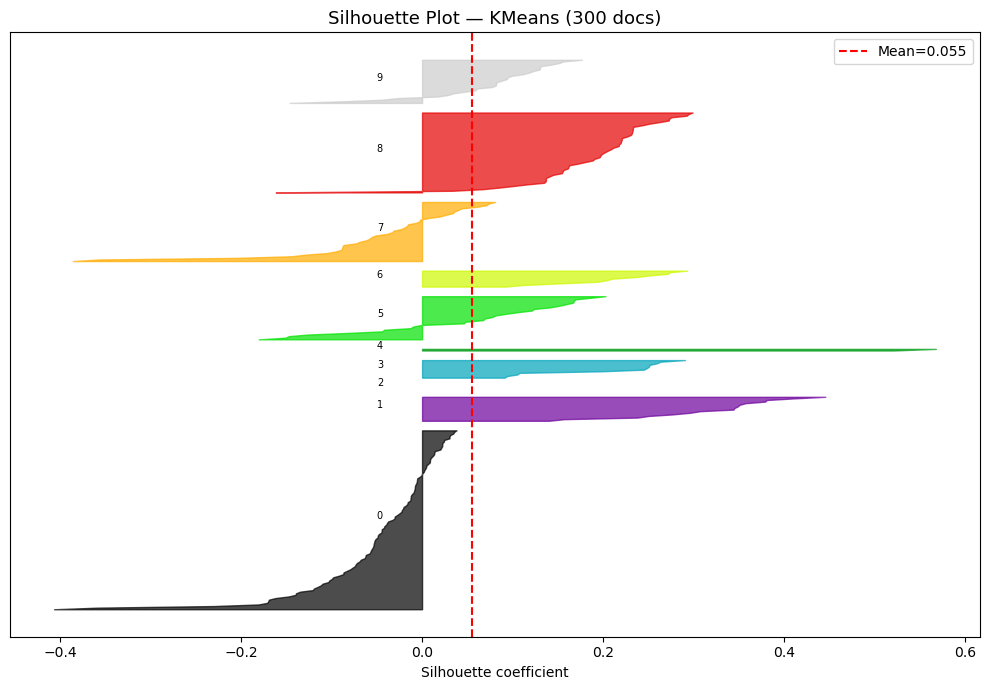

In [12]:
# ── Cell 11: Silhouette Sample Plot ───────────────────────────
print("\nSilhouette sample plot (KMeans) …")
sil_vals  = silhouette_samples(X_test_norm[:300], km_labels[:300])
unique_km = np.unique(km_labels[:300])
y_lower   = 10
fig, ax   = plt.subplots(figsize=(10, 7))
colors    = cm.nipy_spectral(np.linspace(0, 1, len(unique_km)))
for c_idx, cid in enumerate(unique_km):
    vals    = np.sort(sil_vals[km_labels[:300] == cid])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors[c_idx], edgecolor=colors[c_idx], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(vals), str(cid), fontsize=7)
    y_lower = y_upper + 5
ax.axvline(np.mean(sil_vals), color='red', linestyle='--',
           label=f"Mean={np.mean(sil_vals):.3f}")
ax.set_title("Silhouette Plot — KMeans (300 docs)", fontsize=13)
ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([]); ax.legend()
plt.tight_layout()
plt.show()

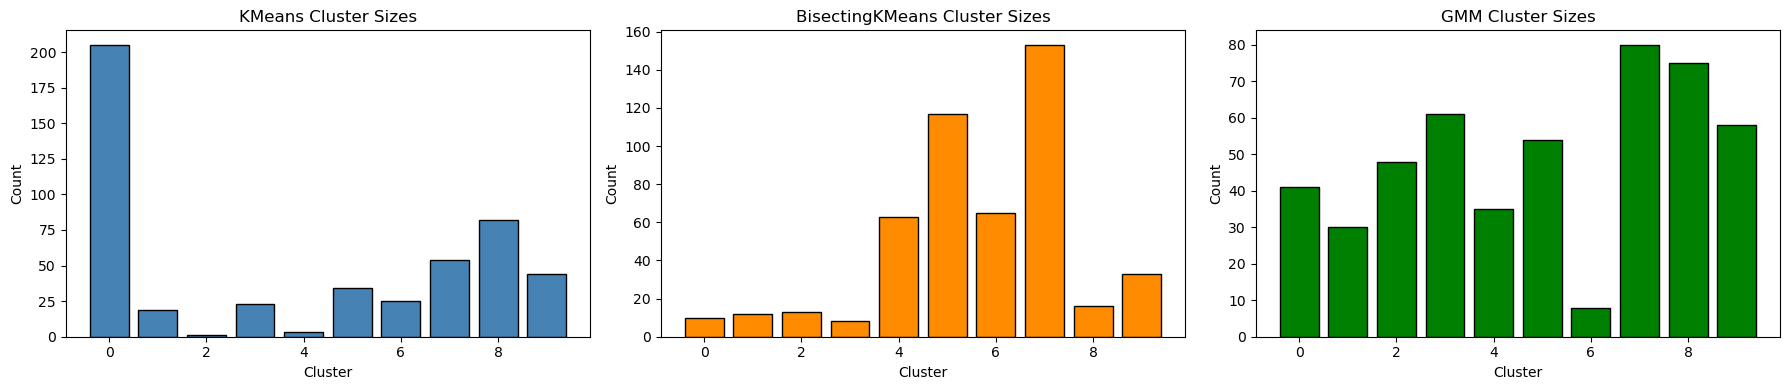

In [13]:
# ── Cell 12: Cluster Size Comparison ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, labels, title, color in zip(
    axes,
    [km_labels, bkm_labels, gmm_labels],
    ['KMeans', 'BisectingKMeans', 'GMM'],
    ['steelblue', 'darkorange', 'green']
):
    sizes = pd.Series(labels).value_counts().sort_index()
    ax.bar(sizes.index, sizes.values, color=color, edgecolor='black')
    ax.set_title(f'{title} Cluster Sizes', fontsize=12)
    ax.set_xlabel('Cluster'); ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Computing t-SNE …
t-SNE done in 1.95s


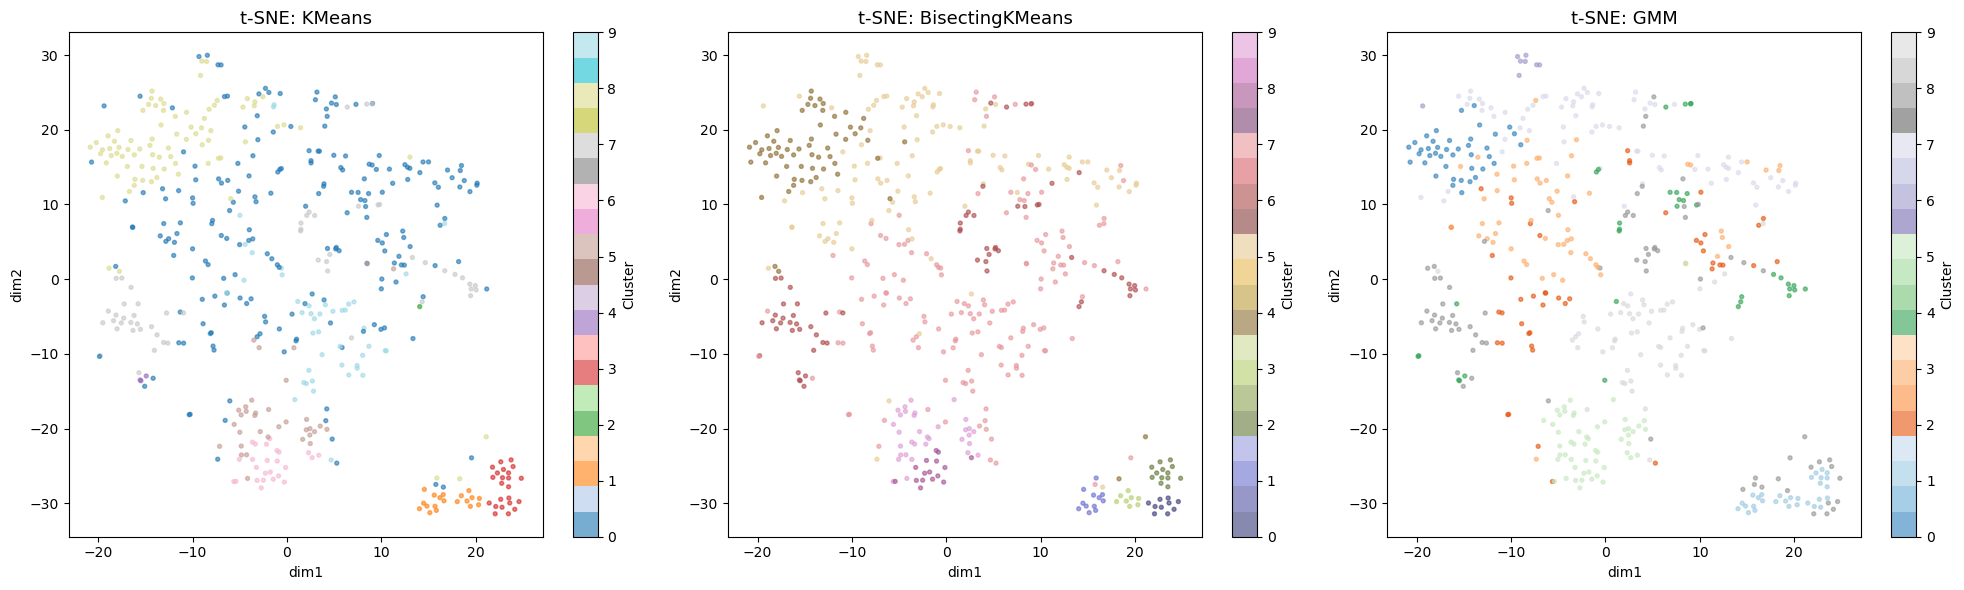

In [14]:
# ── Cell 13: t-SNE Visualization ──────────────────────────────
print("Computing t-SNE …")
n_tsne    = min(500, len(X_test_norm))
t0        = time.time()
tsne      = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_2d      = tsne.fit_transform(X_test_norm[:n_tsne])
print(f"t-SNE done in {time.time()-t0:.2f}s")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, labels, title, cmap in zip(
    axes,
    [km_labels[:n_tsne], bkm_labels[:n_tsne], gmm_labels[:n_tsne]],
    ['KMeans', 'BisectingKMeans', 'GMM'],
    ['tab20', 'tab20b', 'tab20c']
):
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                    c=labels, cmap=cmap, s=8, alpha=0.6)
    ax.set_title(f't-SNE: {title}', fontsize=13)
    ax.set_xlabel('dim1'); ax.set_ylabel('dim2')
    plt.colorbar(sc, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

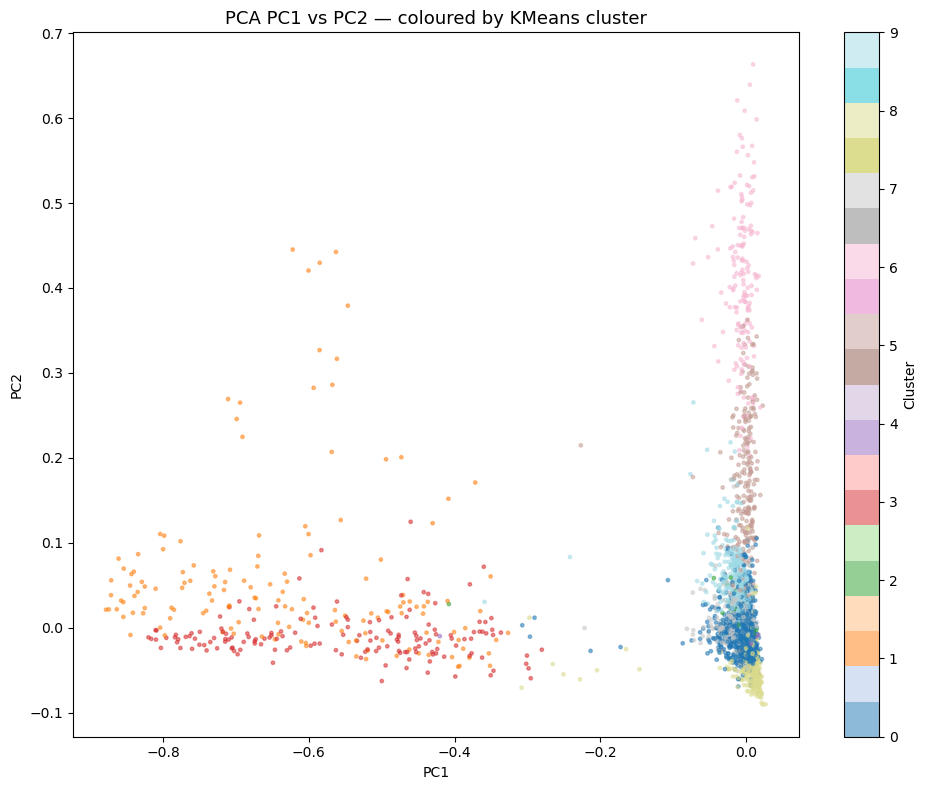

In [15]:
# ── Cell 14: PCA PC1 vs PC2 coloured by KMeans ───────────────
# Use full dataset for a richer plot
full_sdf = (
    train_sdf.select("docID", "pca_50_features")
    .union(val_sdf.select("docID", "pca_50_features"))
    .union(test_sdf.select("docID", "pca_50_features"))
)
full_ids, X_full = sdf_to_numpy(full_sdf)
all_km_preds = km_model.transform(full_sdf).select("docID", "cluster").toPandas()
full_labels_df = pd.DataFrame({"docID": full_ids}).merge(all_km_preds, on="docID")

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(X_full[:, 0], X_full[:, 1],
                c=full_labels_df["cluster"].values,
                cmap='tab20', s=6, alpha=0.5)
ax.set_title('PCA PC1 vs PC2 — coloured by KMeans cluster', fontsize=13)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(sc, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

LDA topic bar charts …


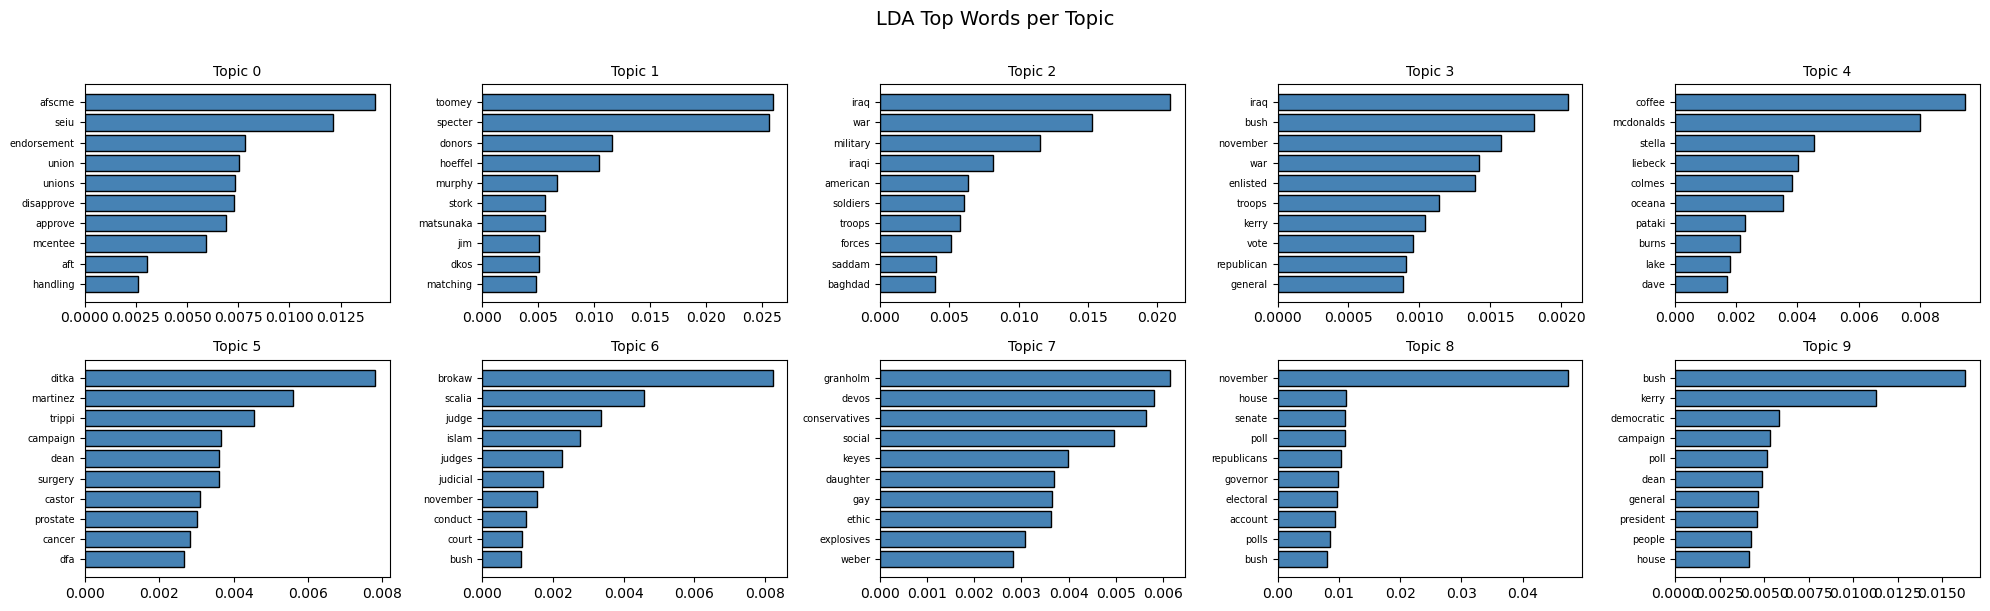

In [16]:
# ── Cell 15: LDA Topic Bar Charts ────────────────────────────
print("LDA topic bar charts …")
topics_pd = lda_model.describeTopics(maxTermsPerTopic=10).toPandas()
n_topics  = len(topics_pd)
n_cols    = 5
n_rows    = (n_topics + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes_flat = axes.flatten()
for _, row in topics_pd.iterrows():
    tid   = int(row['topic'])
    words = [cv_vocabulary[i] if i < len(cv_vocabulary) else f"<{i}>"
             for i in row['termIndices']]
    wts   = row['termWeights']
    ax    = axes_flat[tid]
    ax.barh(words[::-1], wts[::-1], color='steelblue', edgecolor='black')
    ax.set_title(f'Topic {tid}', fontsize=10)
    ax.tick_params(axis='y', labelsize=7)
for i in range(n_topics, len(axes_flat)):
    axes_flat[i].set_visible(False)
plt.suptitle('LDA Top Words per Topic', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

LDA document-topic distribution …


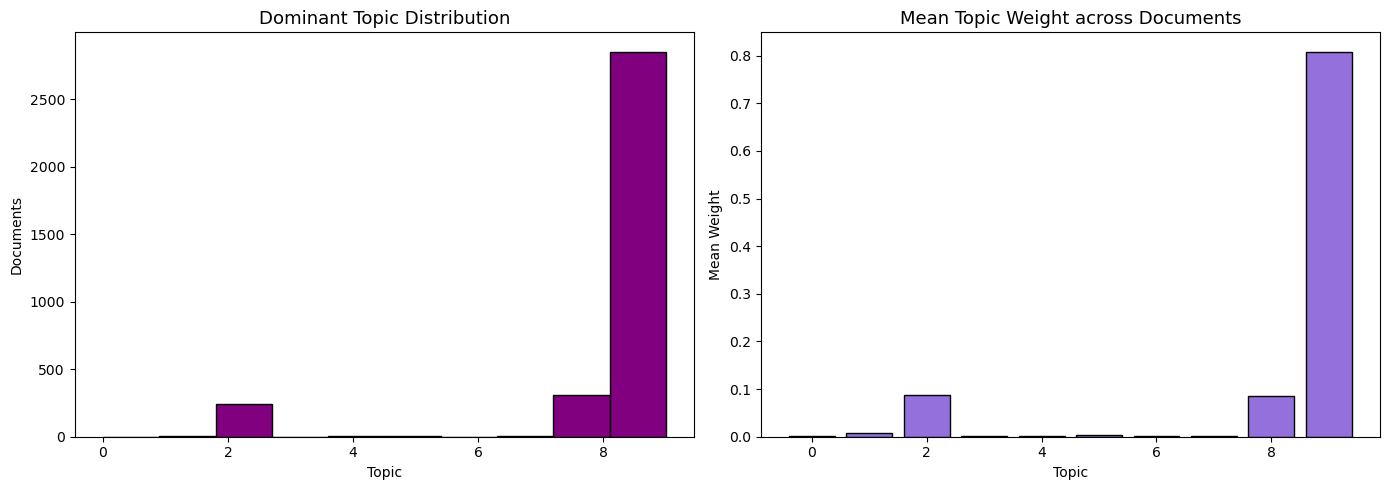

In [17]:
# ── Cell 16: LDA Document-Topic Distribution ─────────────────
print("LDA document-topic distribution …")
doc_topics = lda_model.transform(tfidf_sdf.select("docID", "tf_features"))
doc_topics_pd = doc_topics.select("docID", "topicDistribution").toPandas()
topic_matrix  = np.vstack(
    doc_topics_pd["topicDistribution"].apply(lambda v: v.toArray()).values
)
dominant_topic = np.argmax(topic_matrix, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dominant_topic, bins=n_topics, color='purple', edgecolor='black')
axes[0].set_title('Dominant Topic Distribution', fontsize=13)
axes[0].set_xlabel('Topic'); axes[0].set_ylabel('Documents')
mean_weights = topic_matrix.mean(axis=0)
axes[1].bar(range(len(mean_weights)), mean_weights,
            color='mediumpurple', edgecolor='black')
axes[1].set_title('Mean Topic Weight across Documents', fontsize=13)
axes[1].set_xlabel('Topic'); axes[1].set_ylabel('Mean Weight')
plt.tight_layout()
plt.show()

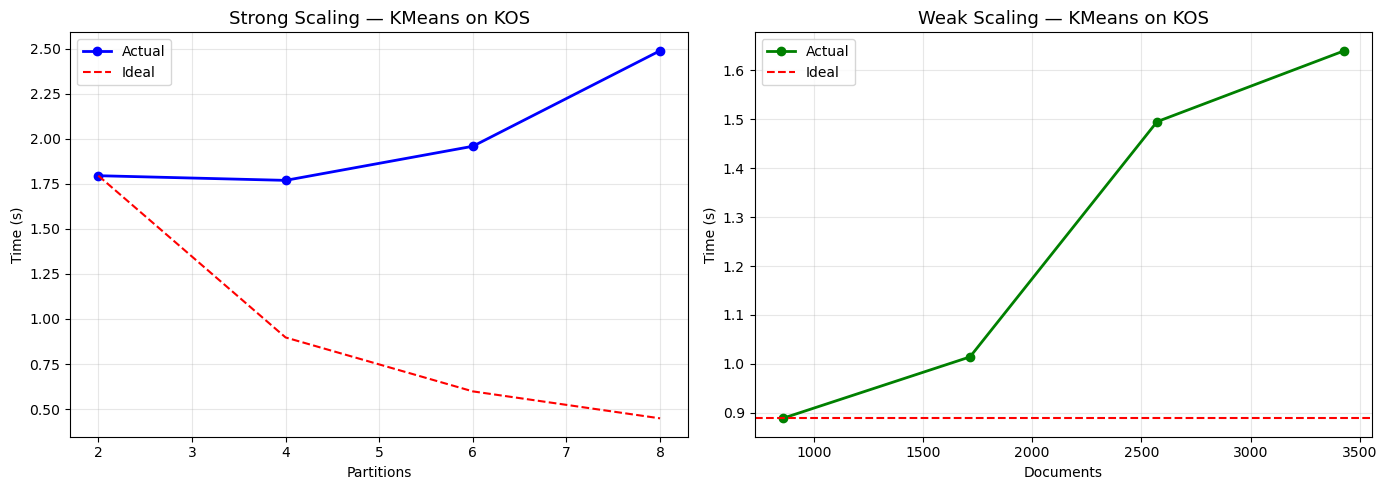

In [18]:
# ── Cell 17: Scalability Plots ────────────────────────────────
ss_df = pd.read_csv('./outputs/strong_scaling.csv')
ws_df = pd.read_csv('./outputs/weak_scaling.csv')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ideal_s = (ss_df['time_s'].iloc[0] *
           ss_df['partitions'].iloc[0] / ss_df['partitions'])
axes[0].plot(ss_df['partitions'], ss_df['time_s'],
             'b-o', label='Actual', linewidth=2)
axes[0].plot(ss_df['partitions'], ideal_s,
             'r--', label='Ideal', linewidth=1.5)
axes[0].set_title('Strong Scaling — KMeans on KOS', fontsize=13)
axes[0].set_xlabel('Partitions'); axes[0].set_ylabel('Time (s)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(ws_df['docs'], ws_df['time_s'],
             'g-o', label='Actual', linewidth=2)
axes[1].axhline(ws_df['time_s'].iloc[0], color='r',
                linestyle='--', label='Ideal')
axes[1].set_title('Weak Scaling — KMeans on KOS', fontsize=13)
axes[1].set_xlabel('Documents'); axes[1].set_ylabel('Time (s)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

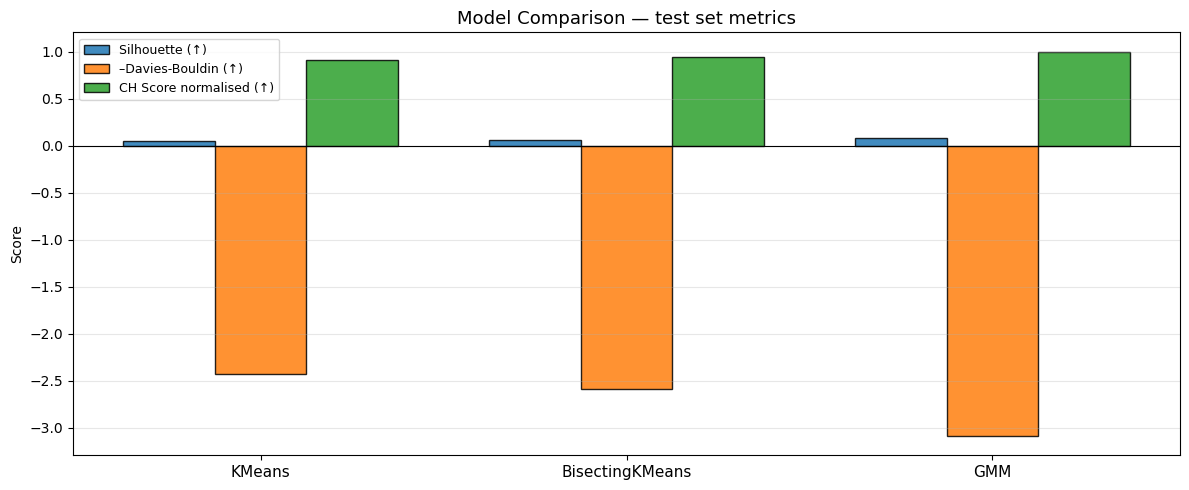

In [19]:
# ── Cell 18: Model Comparison Bar Chart ──────────────────────
model_names = list(metrics.keys())
sil_vals_bar = [metrics[m].get("Silhouette (sklearn)") or 0
                for m in model_names]
db_vals_bar  = [-(metrics[m].get("Davies-Bouldin (↓)") or 0)
                for m in model_names]   # negate so higher=better
ch_raw       = [metrics[m].get("Calinski-Harabasz") or 0
                for m in model_names]
ch_max       = max(ch_raw) if max(ch_raw) > 0 else 1
ch_norm      = [v / ch_max for v in ch_raw]

x     = np.arange(len(model_names))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, sil_vals_bar, width, label='Silhouette (↑)',
       edgecolor='black', alpha=0.85)
ax.bar(x,         db_vals_bar,  width, label='–Davies-Bouldin (↑)',
       edgecolor='black', alpha=0.85)
ax.bar(x + width, ch_norm,      width, label='CH Score normalised (↑)',
       edgecolor='black', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_title('Model Comparison — test set metrics', fontsize=13)
ax.set_ylabel('Score'); ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ── Cell 19: Top Words per KMeans Cluster ────────────────────
print("\nTop words per KMeans cluster …")
bow_schema = StructType([
    StructField("docID",  IntegerType(), False),
    StructField("wordID", IntegerType(), False),
    StructField("count",  IntegerType(), False),
])
kos_bow_sdf = spark.read.schema(bow_schema).parquet(
    os.path.join(PAR_DIR, "kos_docword.parquet"))
bow_pd      = kos_bow_sdf.toPandas()
vocab_map   = pd.DataFrame({"wordID": range(1, len(vocab_list)+1),
                             "word":   vocab_list})
bow_pd      = bow_pd.merge(vocab_map, on="wordID")
bow_pd      = bow_pd.merge(
    pd.DataFrame({"docID": full_ids,
                  "cluster": full_labels_df["cluster"].values}),
    on="docID"
)
n_show_clusters = min(10, int(km_model._java_obj.getK()))
print(f"\nTop 8 words per cluster (first {n_show_clusters}):")
for cid in range(n_show_clusters):
    freq = (bow_pd[bow_pd["cluster"] == cid]
            .groupby("word")["count"].sum()
            .nlargest(8))
    print(f"  Cluster {cid:2d}: {', '.join(freq.index.tolist())}")


Top words per KMeans cluster …

Top 8 words per cluster (first 10):
  Cluster  0: bush, kerry, president, general, administration, people, campaign, time
  Cluster  1: november, poll, house, senate, polls, republicans, governor, bush
  Cluster  2: knowles, murkowski, percent, senate, race, campaign, tony, bush
  Cluster  3: november, bush, kerry, voting, house, republicans, poll, senate
  Cluster  4: donors, dkos, jim, farmer, knowles, matsunaka, nancy, candidates
  Cluster  5: dean, kerry, democratic, edwards, primary, campaign, iowa, gephardt
  Cluster  6: dean, kerry, clark, edwards, poll, lieberman, primary, democratic
  Cluster  7: house, senate, race, republican, democratic, democrats, elections, state
  Cluster  8: iraq, bush, war, administration, iraqi, military, american, president
  Cluster  9: bush, kerry, poll, percent, voters, polls, general, results


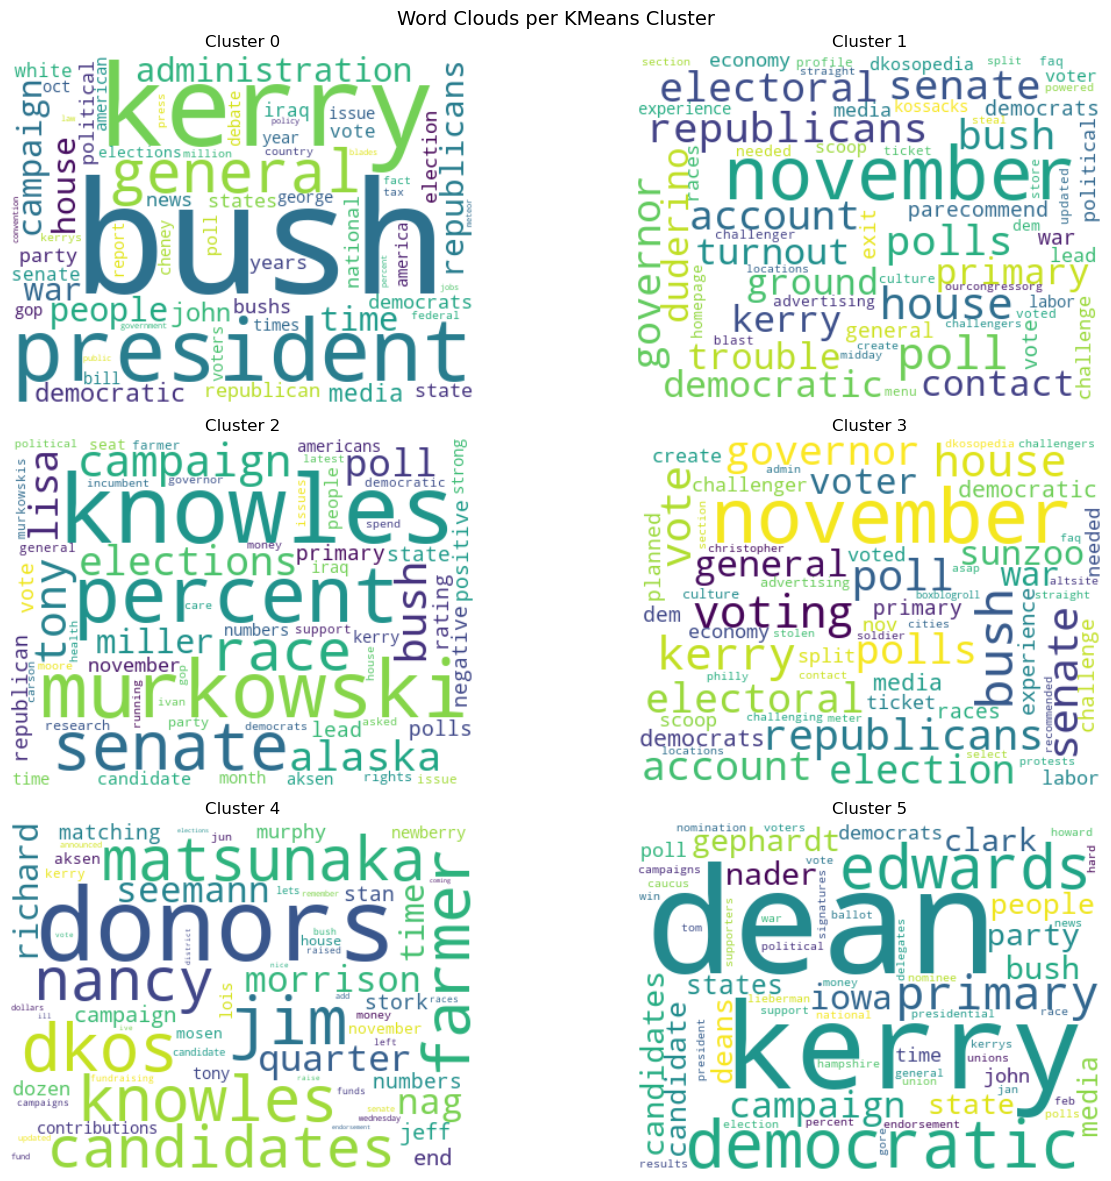

In [22]:
# ── Cell 20: Word Clouds ──────────────────────────
!pip install wordcloud
try:
    from wordcloud import WordCloud
    n_wc   = min(6, n_show_clusters)
    n_c_wc = 2
    n_r_wc = (n_wc + n_c_wc - 1) // n_c_wc
    fig, axes = plt.subplots(n_r_wc, n_c_wc, figsize=(14, n_r_wc * 4))
    axes_flat = axes.flatten()
    for cid in range(n_wc):
        freq_dict = (bow_pd[bow_pd["cluster"] == cid]
                     .groupby("word")["count"].sum().to_dict())
        wc = WordCloud(width=400, height=300, background_color='white',
                       max_words=60, colormap='viridis')
        wc.generate_from_frequencies(freq_dict)
        axes_flat[cid].imshow(wc, interpolation='bilinear')
        axes_flat[cid].set_title(f'Cluster {cid}', fontsize=12)
        axes_flat[cid].axis('off')
    for i in range(n_wc, len(axes_flat)):
        axes_flat[i].set_visible(False)
    plt.suptitle('Word Clouds per KMeans Cluster', fontsize=14)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("wordcloud not installed — skipping (pip install wordcloud)")

In [23]:
# ── Cell 21: Final Summary ────────────────────────────────────
eval_summary = {
    "clustering_metrics": {
        k: {m: v for m, v in mv.items() if v is not None}
        for k, mv in metrics.items()
    },
    "lda": {
        "n_topics":  n_topics,
        "vocab_size": len(cv_vocabulary),
    },
    "scalability": {
        "strong_scaling": ss_df.to_dict(orient='records'),
        "weak_scaling":   ws_df.to_dict(orient='records'),
    }
}
with open("./outputs/final_evaluation_summary.json", "w") as f:
    json.dump(eval_summary, f, indent=2)
print("Saved final_evaluation_summary.json")

print("\nOutput files:")
for fn in sorted(os.listdir("./outputs")):
    sz = os.path.getsize(os.path.join("./outputs", fn)) / 1024
    print(f"  {fn:45s} {sz:8.1f} KB")

print("\nNotebook 4 complete ✓")

Saved final_evaluation_summary.json

Output files:
  evaluation_metrics.csv                             0.2 KB
  final_evaluation_summary.json                      1.6 KB
  lda_perplexity.png                                42.4 KB
  lda_topic_heatmap.png                             83.2 KB
  pca_2d_projection.png                            122.1 KB
  scalability_analysis.png                          80.9 KB
  strong_scaling.csv                                 0.1 KB
  test_cluster_labels.csv                            6.6 KB
  training_results.json                              0.7 KB
  weak_scaling.csv                                   0.2 KB

Notebook 4 complete ✓
